# **Tek nöron forward pass**

In [1]:
inputs = [0.7,0.2,0.3,0.5,0.1,0.9]

weights = [0.8,-0.2,-0.6,0.4,0.3,0.5]


bias = 0.2

e = 2.718281828459045

def linear_comb (inputs, weights, bias):
  toplam = 0
  for i in range(len(inputs)):
    toplam += inputs[i]*weights[i]
  toplam += bias
  return toplam

def activation_func (toplam):
  return (1 /(1 + e**(-toplam)))

def forward_pass (inputs,weights,bias):
  return activation_func(linear_comb(inputs,weights,bias))

print(linear_comb(inputs,weights,bias))
print(forward_pass(inputs,weights,bias))


1.22
0.7720635494267837


# **3 Nöron Forward Pass**

In [2]:
inputs = [0.7,0.2,0.3,0.5,0.1,0.9]

weights = [[0.8,-0.2,-0.6,0.4,0.3,0.5],
           [0.4,0.6,-0.1,0.7,-0.8,0.3],
           [-0.5,-0.3,0.7,0.8,0.1,0.4]]

bias = [0.2,2.1,0.9]

def forward_pass2 (inputs,weights,bias):
  outputs = []

  for i in range(len(weights)):
    outputs.append(forward_pass(inputs,weights[i],bias[i]))

  return outputs

outputs = forward_pass2(inputs,weights,bias)
print(outputs)


[0.7720635494267837, 0.9530238543217163, 0.8130573860319537]


# **Loss Function**

In [3]:
targets = [0.1,0.8,0.7]

def loss_mse (outputs, targets):
  squared_loss = 0

  for i in range(len(outputs)):
    squared_loss += (outputs[i] - targets[i])**2

  mse_loss = squared_loss / (len(outputs))

  return mse_loss

print(outputs,targets)
print(loss_mse(outputs,targets))


[0.7720635494267837, 0.9530238543217163, 0.8130573860319537] [0.1, 0.8, 0.7]
0.162622562331993


# **Loss Eğrisi**

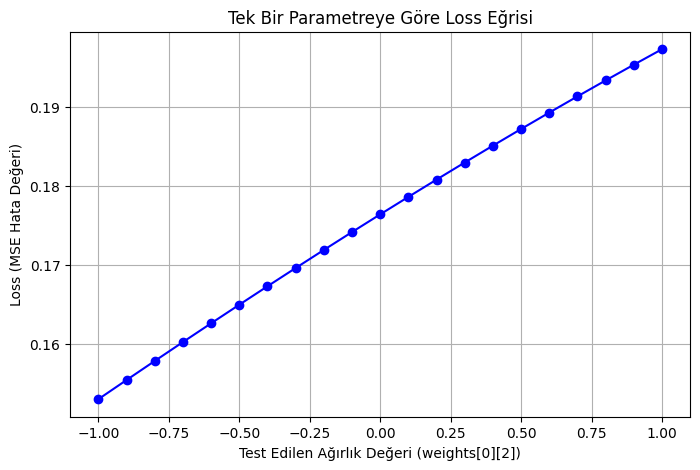

In [4]:
import matplotlib.pyplot as plt

weight_history = []
loss_history = []

referance_weight = weights[0][2]

test_weight = -1.0

while test_weight <= 1.0 :
  weights[0][2] = test_weight
  loss_history.append(loss_mse(forward_pass2(inputs,weights,bias),targets))
  weight_history.append(test_weight)
  test_weight += 0.1

weights[0][2] = referance_weight

plt.figure(figsize=(8, 5))
plt.plot(weight_history, loss_history, marker='o', color='b', linestyle='-')
plt.title("Tek Bir Parametreye Göre Loss Eğrisi")
plt.xlabel("Test Edilen Ağırlık Değeri (weights[0][2])")
plt.ylabel("Loss (MSE Hata Değeri)")
plt.grid(True)
plt.show()

# **Basit Gradient Dongusu**

In [5]:
learning_rate = 0.1
h = 0.00001
epochs = 100

for epoch in range(epochs):

  outputs_current = forward_pass2(inputs, weights, bias)
  loss_current = loss_mse(outputs_current, targets)

  weights[0][2] += h
  outputs_h = forward_pass2(inputs, weights, bias)
  loss_h = loss_mse(outputs_h, targets)

  weights[0][2] -= h

  gradient = (loss_h - loss_current) / h

  weights[0][2] -= learning_rate * gradient

  if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss_current:.5f} | Yeni Ağırlık: {weights[0][2]:.5f}")



Epoch 0 | Loss: 0.16262 | Yeni Ağırlık: -0.60237
Epoch 10 | Loss: 0.16206 | Yeni Ağırlık: -0.62605
Epoch 20 | Loss: 0.16150 | Yeni Ağırlık: -0.64977
Epoch 30 | Loss: 0.16093 | Yeni Ağırlık: -0.67355
Epoch 40 | Loss: 0.16037 | Yeni Ağırlık: -0.69736
Epoch 50 | Loss: 0.15980 | Yeni Ağırlık: -0.72123
Epoch 60 | Loss: 0.15923 | Yeni Ağırlık: -0.74514
Epoch 70 | Loss: 0.15865 | Yeni Ağırlık: -0.76909
Epoch 80 | Loss: 0.15808 | Yeni Ağırlık: -0.79309
Epoch 90 | Loss: 0.15750 | Yeni Ağırlık: -0.81713
